<a href="https://colab.research.google.com/github/ShreyasD21/Analy/blob/main/QC_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1 - Build and Understand a Quantum Circuit**

In [8]:
!pip install qiskit qiskit-aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=914663f18d80b0077d4872fc90ee7917dbe40b83e154f090540e954f755341ec
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [9]:
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector

In [10]:
qc_step1 = QuantumCircuit(2)
qc_step1.h(0)
state1 = Statevector.from_instruction(qc_step1)
print("After H Gate:")
display(state1.draw('latex'))

After H Gate:


<IPython.core.display.Latex object>

In [12]:
qc_step2 = qc_step1.copy()
qc_step2.cx(0, 1)
state2 = Statevector.from_instruction(qc_step2)
print("\nAfter CNOT Gate:")
display(state2.draw('latex'))


After CNOT Gate:


<IPython.core.display.Latex object>

In [14]:
state = Statevector.from_instruction(qc_step2)
print("Statevector:")
display(state.draw('latex'))

Statevector:


<IPython.core.display.Latex object>

**Importance of the State Vector:**
The state vector represents the "pure" mathematical evidence of entanglement, as it gives the state of the system prior to its measurement. It shows that one cannot express the state of the first qubit without considering the second qubit. This shows that the Hadamard and CNOT gates have succeeded in combining two separate qubits into one.

In [15]:
qc_step2.measure_all()

In [16]:
simulator = Aer.get_backend('qasm_simulator')
job = simulator.run(qc_step2, shots=1024)
counts = job.result().get_counts()


Measurement Counts: {'11': 483, '00': 541}


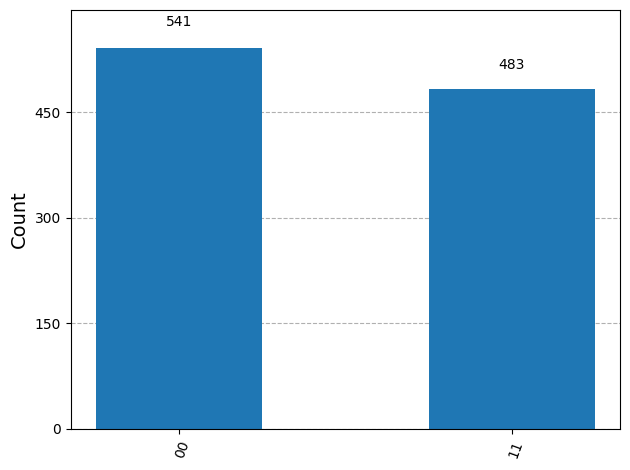

In [17]:
print("\nMeasurement Counts:", counts)
display(plot_histogram(counts))

The histogram serves as experimental evidence by indicating the distribution of outputs across different experiments. For an entangled system, the histogram illustrates perfect correlation of qubits, where only the 00 and 11 states can be seen without any contribution from the superposed states 01 and 10, hence proving entanglement.

**Task 2 - Grover’s Algorithm: Understand and Apply**

In [30]:
qc_init = QuantumCircuit(2)
qc_init.h([0, 1])
state1 = Statevector.from_instruction(qc_init)
print("Step 1: Initialization")
display(state1.draw('latex'))

Step 1: Initialization


<IPython.core.display.Latex object>

In [33]:
qc_oracle = qc_init.copy()
qc_oracle.cz(0, 1)
state2 = Statevector.from_instruction(qc_oracle)
print("\nStep 2: The Oracle (State 11 is phase-flipped to negative)\n")
display(state2.draw('latex'))


Step 2: The Oracle (State |11> is phase-flipped to negative)



<IPython.core.display.Latex object>

In [34]:
qc_diff = qc_oracle.copy()
qc_diff.h([0, 1])
qc_diff.z([0, 1])
qc_diff.cz(0, 1)
qc_diff.h([0, 1])
state3 = Statevector.from_instruction(qc_diff)
print("\nStep 4: The Diffuser (Amplitude of 11 is amplified)")
display(state3.draw('latex'))


Step 4: The Diffuser (Amplitude of |11> is amplified)


<IPython.core.display.Latex object>

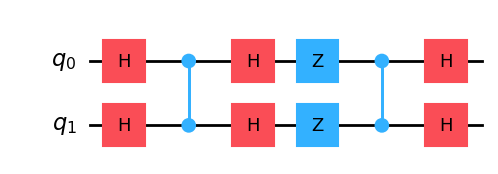

In [35]:
display(qc_diff.draw(output='mpl'))

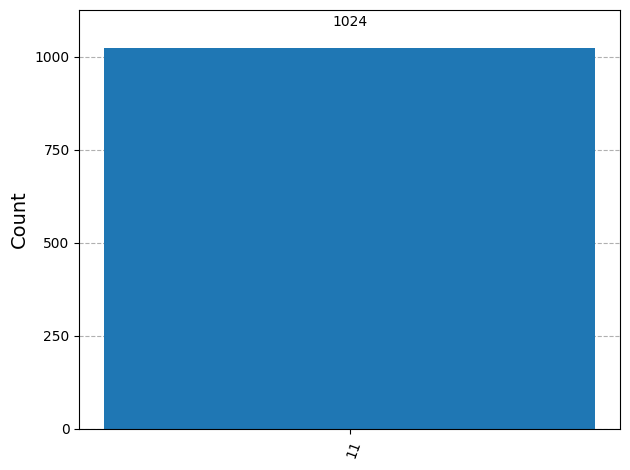

In [36]:
qc_diff.measure_all()
from qiskit_aer import Aer
backend = Aer.get_backend('qasm_simulator')
counts = backend.run(qc_diff).result().get_counts()
display(plot_histogram(counts))

**Importance of the Histogram Outcome**
The histogram is the experimental proof, which displays a peak with 100% probability for the desired outcome 11. This indicates the effectiveness of Amplitude Amplification in showing that all probability was removed from the three "wrong" states, while the entire quantum system converged to the correct answer in one step.